[[  6609.   2100.      0.  -1710.]
 [  2100. -33606.  51840. -14400.]
 [     0.  51840. -40425.    500.]
 [ -1710. -14400.    500.   6569.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


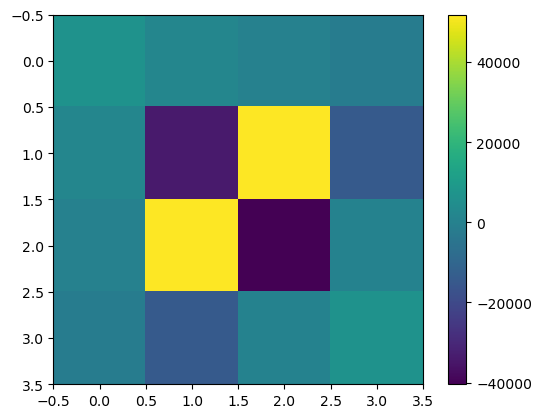

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Fri Aug  7 15:10:36 2026

@author: MarcelSeelbach(MSE)
"""
import numpy as np 
import pickle 
import matplotlib.pyplot as plt

whereToSave= 'C:/Users/MarcelSeelbach(MSE)/Documents/Gitlab/2DCS_QUBOs/test/Plots/SmallestProblem'

k=0
QUBO=  pickle.load( open( whereToSave+'QUBOLambdIt'+str(k)+'.p', "rb" ) )
print(QUBO.toarray())
plt.imshow(QUBO.toarray())
plt.colorbar()

oldQUBO=QUBO.toarray()
for k in range(10):
    QUBO=  pickle.load( open( whereToSave+'QUBOLambdIt'+str(k)+'.p', "rb" ) )
    print(oldQUBO -QUBO.toarray())
    oldQUBO=QUBO.toarray()


In [2]:
QUBO=  pickle.load( open( whereToSave+'QUBOLambdIt'+str(k)+'.p', "rb" ) )
QUBO.toarray()

array([[  6609.,   2100.,      0.,  -1710.],
       [  2100., -33606.,  51840., -14400.],
       [     0.,  51840., -40425.,    500.],
       [ -1710., -14400.,    500.,   6569.]])

In [3]:
mat=QUBO.toarray()
mat/4

array([[  1652.25,    525.  ,      0.  ,   -427.5 ],
       [   525.  ,  -8401.5 ,  12960.  ,  -3600.  ],
       [     0.  ,  12960.  , -10106.25,    125.  ],
       [  -427.5 ,  -3600.  ,    125.  ,   1642.25]])

In [4]:
bias= 0.5*mat@ np.ones(4)

In [5]:
bias

array([ 3499.5,  2967. ,  5957.5, -4520.5])

In [6]:
normalization= np.max( np.abs( QUBO))

In [10]:
Matrix=QUBO.toarray()/normalization 
MatrixRounded= Matrix.copy()
MatrixRounded[np.where( np.abs(Matrix ) <0.1 )]=0

In [9]:
Matrix

array([[ 0.12748843,  0.04050926,  0.        , -0.03298611],
       [ 0.04050926, -0.64826389,  1.        , -0.27777778],
       [ 0.        ,  1.        , -0.77980324,  0.00964506],
       [-0.03298611, -0.27777778,  0.00964506,  0.12671682]])

In [16]:
def Energy(vec, Mat):
    return vec.T @Mat@vec
import itertools
lst = list(itertools.product([0,1], repeat=4))
saveToPlot=[]
for elem in lst:
    print( str(elem)+ ': '+ str(Energy(np.array(elem), Matrix )))
    print( str(elem)+ ': '+ str(Energy(np.array(elem), MatrixRounded )))

    saveToPlot.append (Energy(np.array(elem), MatrixRounded))


(0, 0, 0, 0): 0.0
(0, 0, 0, 0): 0.0
(0, 0, 0, 1): 0.12671682098765433
(0, 0, 0, 1): 0.12671682098765433
(0, 0, 1, 0): -0.7798032407407407
(0, 0, 1, 0): -0.7798032407407407
(0, 0, 1, 1): -0.6337962962962962
(0, 0, 1, 1): -0.6530864197530863
(0, 1, 0, 0): -0.6482638888888889
(0, 1, 0, 0): -0.6482638888888889
(0, 1, 0, 1): -1.0771026234567902
(0, 1, 0, 1): -1.0771026234567902
(0, 1, 1, 0): 0.5719328703703704
(0, 1, 1, 0): 0.5719328703703704
(0, 1, 1, 1): 0.1623842592592593
(0, 1, 1, 1): 0.14309413580246919
(1, 0, 0, 0): 0.12748842592592594
(1, 0, 0, 0): 0.12748842592592594
(1, 0, 0, 1): 0.18823302469135805
(1, 0, 0, 1): 0.25420524691358026
(1, 0, 1, 0): -0.6523148148148148
(1, 0, 1, 0): -0.6523148148148148
(1, 0, 1, 1): -0.5722800925925925
(1, 0, 1, 1): -0.5255979938271604
(1, 1, 0, 0): -0.43975694444444435
(1, 1, 0, 0): -0.520775462962963
(1, 1, 0, 1): -0.9345679012345679
(1, 1, 0, 1): -0.9496141975308642
(1, 1, 1, 0): 0.780439814814815
(1, 1, 1, 0): 0.6994212962962963
(1, 1, 1, 1): 0.30

In [18]:
MatrixRounded

array([[ 0.12748843,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.64826389,  1.        , -0.27777778],
       [ 0.        ,  1.        , -0.77980324,  0.        ],
       [ 0.        , -0.27777778,  0.        ,  0.12671682]])

For the smallproblem the small coefficients do not change GS

[[  6009.   1200.      0.  -3330.]
 [  1200. -23397.  15750.  -6300.]
 [     0.  15750. -19970.    500.]
 [ -3330.  -6300.    500.  12975.]]


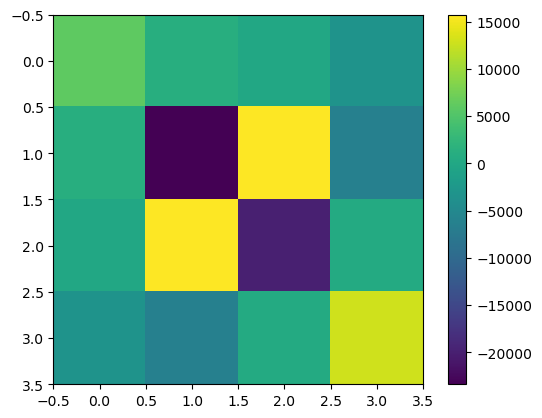

In [64]:
whereToSave= 'C:/Users/MarcelSeelbach(MSE)/Documents/Gitlab/2DCS_QUBOs/test/Plots/SmallestProblemNoSolPos'

k=8
QUBO=  pickle.load( open( whereToSave+'QUBOLambdIt'+str(k)+'.p', "rb" ) )
print(QUBO.toarray())
plt.imshow(QUBO.toarray())
plt.colorbar()

In [65]:
normalization= np.max( np.abs( QUBO))

In [66]:
Matrix=QUBO.toarray()/normalization 
MatrixRounded= Matrix.copy()
MatrixRounded[np.where( np.abs(Matrix ) <0.1 )]=0

In [67]:
def Energy(vec, Mat):
    return vec.T @Mat@vec

lst = list(itertools.product([0,1], repeat=4))
saveToPlot=[]
for elem in lst:
    print( str(elem)+ ': '+ str(Energy(np.array(elem), Matrix )))
    print( str(elem)+ ': '+ str(Energy(np.array(elem), MatrixRounded )))

    saveToPlot.append (Energy(np.array(elem), MatrixRounded))

(0, 0, 0, 0): 0.0
(0, 0, 0, 0): 0.0
(0, 0, 0, 1): 0.5545582767021413
(0, 0, 0, 1): 0.5545582767021413
(0, 0, 1, 0): -0.853528230114972
(0, 0, 1, 0): -0.853528230114972
(0, 0, 1, 1): -0.2562294311236484
(0, 0, 1, 1): -0.2989699534128307
(0, 1, 0, 0): -1.0
(0, 1, 0, 0): -1.0
(0, 1, 0, 1): -0.9839723041415565
(0, 1, 0, 1): -0.9839723041415565
(0, 1, 1, 0): -0.5072017780057272
(0, 1, 1, 0): -0.5072017780057272
(0, 1, 1, 1): -0.44843355985810146
(0, 1, 1, 1): -0.4911740821472838
(1, 0, 0, 0): 0.25682779843569686
(1, 0, 0, 0): 0.25682779843569686
(1, 0, 0, 1): 0.5267341966918835
(1, 0, 0, 1): 0.5267341966918835
(1, 0, 1, 0): -0.5967004316792752
(1, 0, 1, 0): -0.5967004316792752
(1, 0, 1, 1): -0.28405351113390614
(1, 0, 1, 1): -0.3267940334230885
(1, 1, 0, 0): -0.6405949480702655
(1, 1, 0, 0): -0.7431722015643032
(1, 1, 0, 1): -0.9092191306577768
(1, 1, 0, 1): -1.0117963841518143
(1, 1, 1, 0): -0.14779672607599265
(1, 1, 1, 0): -0.2503739795700303
(1, 1, 1, 1): -0.37368038637432144
(1, 1, 1, 

In [63]:
Matrix-MatrixRounded

array([[0.        , 0.05128863, 0.        , 0.        ],
       [0.05128863, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.02137026],
       [0.        , 0.        , 0.02137026, 0.        ]])

In [57]:
Matrix

array([[ 0.2568278 ,  0.05128863,  0.        , -0.14232594],
       [ 0.05128863, -1.        ,  0.67316323, -0.26926529],
       [ 0.        ,  0.67316323, -0.85352823,  0.02137026],
       [-0.14232594, -0.26926529,  0.02137026,  0.55455828]])

In [58]:
MatrixRounded

array([[ 0.2568278 ,  0.        ,  0.        , -0.14232594],
       [ 0.        , -1.        ,  0.67316323, -0.26926529],
       [ 0.        ,  0.67316323, -0.85352823,  0.        ],
       [-0.14232594, -0.26926529,  0.        ,  0.55455828]])

[[  4484.      0.   1780.      0.      0.   5620.      0.    500.    500.]
 [     0.   6609.   6480.   2100.      0.      0.  -1710.   -400.      0.]
 [  1780.   6480.   6147.      0.      0.   6900.   -648.    500.    500.]
 [     0.   2100.      0. -33606.  51840.  46080. -14400.  -6400.      0.]
 [     0.      0.      0.  51840. -40425.  41472.    500.      0.  -4860.]
 [  5620.      0.   6900.  46080.  41472. -30348.      0.    500.    500.]
 [     0.  -1710.   -648. -14400.    500.      0.   6569.   3600.      0.]
 [   500.   -400.    500.  -6400.      0.    500.   3600.   1026.    532.]
 [   500.      0.    500.      0.  -4860.    500.      0.    532.    675.]]


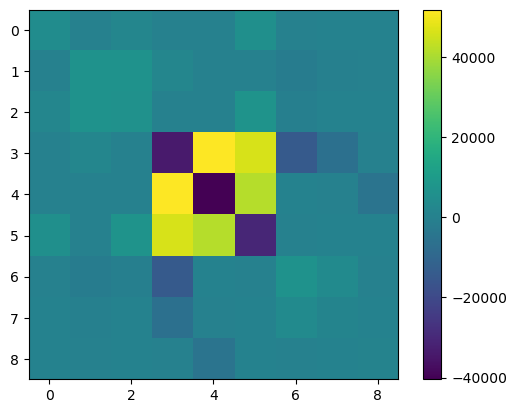

In [68]:
whereToSave= 'C:/Users/MarcelSeelbach(MSE)/Documents/Gitlab/2DCS_QUBOs/test/Plots/SmallProblem'

k=8
QUBO=  pickle.load( open( whereToSave+'QUBOLambdIt'+str(k)+'.p', "rb" ) )
print(QUBO.toarray())
plt.imshow(QUBO.toarray())
plt.colorbar()

In [69]:
normalization= np.max( np.abs( QUBO))
Matrix=QUBO.toarray()/normalization 
MatrixRounded= Matrix.copy()
MatrixRounded[np.where( np.abs(Matrix ) <0.1 )]=0

In [74]:
def Energy(vec, Mat):
    return vec.T @Mat@vec

lst = list(itertools.product([0,1], repeat=9))
saveToPlot=[]

minEn=0
minEnRound=0

for elem in lst:
    print( str(elem)+ ': '+ str(Energy(np.array(elem), Matrix )))
    print( str(elem)+ ': '+ str(Energy(np.array(elem), MatrixRounded )))

    if Energy(np.array(elem), Matrix )<minEn:
        minEn = Energy(np.array(elem), Matrix )
    if Energy(np.array(elem), MatrixRounded )< minEnRound:
        minEnRound = Energy(np.array(elem), MatrixRounded )

    saveToPlot.append (Energy(np.array(elem), MatrixRounded))
print(minEn)
print(minEnRound)

(0, 0, 0, 0, 0, 0, 0, 0, 0): 0.0
(0, 0, 0, 0, 0, 0, 0, 0, 0): 0.0
(0, 0, 0, 0, 0, 0, 0, 0, 1): 0.013020833333333334
(0, 0, 0, 0, 0, 0, 0, 0, 1): 0.0
(0, 0, 0, 0, 0, 0, 0, 1, 0): 0.019791666666666666
(0, 0, 0, 0, 0, 0, 0, 1, 0): 0.0
(0, 0, 0, 0, 0, 0, 0, 1, 1): 0.05333719135802469
(0, 0, 0, 0, 0, 0, 0, 1, 1): 0.0
(0, 0, 0, 0, 0, 0, 1, 0, 0): 0.12671682098765433
(0, 0, 0, 0, 0, 0, 1, 0, 0): 0.12671682098765433
(0, 0, 0, 0, 0, 0, 1, 0, 1): 0.13973765432098767
(0, 0, 0, 0, 0, 0, 1, 0, 1): 0.12671682098765433
(0, 0, 0, 0, 0, 0, 1, 1, 0): 0.2853973765432099
(0, 0, 0, 0, 0, 0, 1, 1, 0): 0.12671682098765433
(0, 0, 0, 0, 0, 0, 1, 1, 1): 0.3189429012345679
(0, 0, 0, 0, 0, 0, 1, 1, 1): 0.12671682098765433
(0, 0, 0, 0, 0, 1, 0, 0, 0): -0.5854166666666667
(0, 0, 0, 0, 0, 1, 0, 0, 0): -0.5854166666666667
(0, 0, 0, 0, 0, 1, 0, 0, 1): -0.5531057098765432
(0, 0, 0, 0, 0, 1, 0, 0, 1): -0.5854166666666667
(0, 0, 0, 0, 0, 1, 0, 1, 0): -0.5463348765432099
(0, 0, 0, 0, 0, 1, 0, 1, 0): -0.5854166666666667
(0

In [78]:
Matrix- MatrixRounded

array([[ 0.08649691,  0.        ,  0.03433642,  0.        ,  0.        ,
         0.        ,  0.        ,  0.00964506,  0.00964506],
       [ 0.        ,  0.        ,  0.        ,  0.04050926,  0.        ,
         0.        , -0.03298611, -0.00771605,  0.        ],
       [ 0.03433642,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.0125    ,  0.00964506,  0.00964506],
       [ 0.        ,  0.04050926,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.00964506,  0.        , -0.09375   ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.00964506,  0.00964506],
       [ 0.        , -0.03298611, -0.0125    ,  0.        ,  0.00964506,
         0.        ,  0.        ,  0.06944444,  0.        ],
       [ 0.00964506, -0.00771605,  0.00964506,  0.        ,  0